# K-Nearest Neighbors (KNN) - Crop Recommendation

## Overview
K-Nearest Neighbors (KNN) is a **non-parametric, instance-based learning algorithm** that classifies data points based on the majority class of their k nearest neighbors in the feature space.

### Key Concepts:
- **Instance-Based Learning**: No explicit model training - predictions made using stored training data
- **Lazy Learning**: Learning is deferred until prediction time
- **Distance Metrics**: Uses distance measures (Euclidean, Manhattan, etc.) to find nearest neighbors
- **Voting Mechanism**: Classification based on majority vote of k nearest neighbors

### How KNN Works:
1. **Training Phase**: Store all training examples
2. **Prediction Phase**: 
   - Calculate distance from query point to all training points
   - Select k nearest neighbors
   - Predict class based on majority vote (classification) or average (regression)

### Distance Metrics:
- **Euclidean**: `√(Σ(xi - yi)²)` - Standard straight-line distance
- **Manhattan**: `Σ|xi - yi|` - City block distance

### Advantages:
- Simple to understand and implement
- Works well for non-linear data
- Can be used for both classification and regression

### Disadvantages:
- Computationally expensive (stores all training data)
- Requires feature scaling
- Performance degrades with high-dimensional data (curse of dimensionality)


In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    cross_validate,
    learning_curve
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [41]:
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

print(df.head()) 

       N      P      K  temperature   humidity        ph    rainfall      crop
0   17.0  136.0  196.0    23.871923  90.499390  5.882156  103.054809     apple
1   49.0   69.0   82.0    18.315615  15.361435  7.263119   81.787105  chickpea
2   74.0   49.0   38.0    23.314104  71.450905  7.488014  164.497037      jute
3  104.0   35.0   28.0    27.510061  50.666872  6.983732  143.995555    coffee
4   23.0   72.0   84.0    19.020613  17.131591  6.920251   79.926981  chickpea


In [42]:
feature_col = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

X = df[feature_col]
y = df['crop']

In [43]:
## data preprocessing
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [44]:
# X_train.head()
X_train.shape

(1320, 7)

In [46]:
X_test.shape
# X_test.head()

(330, 7)

In [47]:
# Standard Scalar
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [48]:
X_train.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,50.558649,53.443733,48.063172,25.632286,71.524225,6.493445,103.854957
std,36.795041,33.263771,50.547857,5.039335,22.215540,0.781609,55.502902
min,0.000000,5.000000,5.000000,9.467960,14.273280,3.525366,20.360011
25%,22.000000,27.000000,20.436428,22.712028,60.052333,5.999508,64.853498
50%,37.000000,52.000000,31.075086,25.655229,80.537643,6.418436,94.707894
75%,84.568728,68.000000,49.000000,28.543408,89.987078,6.943648,129.026885
max,136.000000,145.000000,205.000000,42.936054,99.981876,9.935091,298.560117


In [51]:
X_train_scaler_df = pd.DataFrame(X_train_scaler, columns=feature_col)

In [55]:
X_train_scaler_df

,N,P,K,temperature,humidity,ph,rainfall
0,0.474193,0.467841,0.077913,0.004494,0.955585,0.409488,-0.917420
1,0.256690,-0.133641,-0.080413,-0.964089,0.584205,-0.318187,2.455326
2,-0.830825,0.708434,-0.496018,1.834310,-1.471886,-1.680727,0.800177
3,-0.830825,0.618212,-0.634554,2.066780,-1.256794,-2.219284,1.010040
4,0.555757,-0.043419,-0.594972,-0.104103,-0.700086,-0.899351,-0.463109
...,...,...,...,...,...,...,...
1315,-0.504570,-1.276458,-0.337693,-0.111876,0.981211,-0.367987,0.558506
1316,-0.368631,0.497915,-0.456437,-1.171415,-2.099747,-0.862703,-0.356719
1317,1.045139,-0.855421,0.117494,-0.186325,0.632475,-0.179618,-0.988810
1318,1.809553,-0.701561,-0.304563,0.268307,-0.438428,-0.179224,1.443607


In [58]:
print(np.round(X_train_scaler_df.describe(), 1))


            N       P       K  temperature  humidity      ph  rainfall
count  1320.0  1320.0  1320.0       1320.0    1320.0  1320.0    1320.0
mean      0.0    -0.0     0.0         -0.0      -0.0     0.0      -0.0
std       1.0     1.0     1.0          1.0       1.0     1.0       1.0
min      -1.4    -1.5    -0.9         -3.2      -2.6    -3.8      -1.5
25%      -0.8    -0.8    -0.5         -0.6      -0.5    -0.6      -0.7
50%      -0.4    -0.0    -0.3          0.0       0.4    -0.1      -0.2
75%       0.9     0.4     0.0          0.6       0.8     0.6       0.5
max       2.3     2.8     3.1          3.4       1.3     4.4       3.5


In [59]:
X_test_scaler_df = pd.DataFrame(X_test_scaler, columns=feature_col)

In [61]:
print(np.round(X_train_scaler_df.describe(), 1))

            N       P       K  temperature  humidity      ph  rainfall
count  1320.0  1320.0  1320.0       1320.0    1320.0  1320.0    1320.0
mean      0.0    -0.0     0.0         -0.0      -0.0     0.0      -0.0
std       1.0     1.0     1.0          1.0       1.0     1.0       1.0
min      -1.4    -1.5    -0.9         -3.2      -2.6    -3.8      -1.5
25%      -0.8    -0.8    -0.5         -0.6      -0.5    -0.6      -0.7
50%      -0.4    -0.0    -0.3          0.0       0.4    -0.1      -0.2
75%       0.9     0.4     0.0          0.6       0.8     0.6       0.5
max       2.3     2.8     3.1          3.4       1.3     4.4       3.5


In [62]:
knn_cls = KNeighborsClassifier(
                n_neighbors=5, 
                weights='uniform', 
                algorithm='auto', 
                metric='euclidean'
            )
knn_cls.fit(X_train_scaler_df, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [63]:
y_pred = knn_cls.predict(X_test_scaler_df)

In [64]:
y_pred

array([19,  6, 21,  2, 15, 19, 20,  0, 10,  7, 14,  5,  4,  3, 20,  2, 12,
        1,  2, 14, 13, 15,  2,  0,  0, 12,  6,  1, 20, 17, 13,  7,  5, 13,
       11,  0,  1, 15, 19,  4,  8, 15, 14,  9,  9,  6, 13,  2, 11, 20, 19,
       12,  6,  1,  9,  8, 19,  6, 10,  9, 13,  1, 15,  8, 16,  7, 19,  2,
       17, 18,  7,  5, 17, 17, 19, 17,  5,  5, 20, 11,  8,  8,  9,  9,  9,
        7, 21, 10, 10,  6,  1, 13, 16,  2, 16, 20,  3, 19, 20, 21,  5, 17,
        5,  6, 21,  2, 20, 12, 17,  7, 15, 21,  0,  3,  3, 16,  8,  5, 14,
       16,  2,  6, 12,  7, 10,  3, 10,  7, 14,  1, 17, 15, 17,  0, 10, 17,
       19, 10, 17, 21, 18,  2, 18, 15,  6,  3,  8, 11, 17,  3, 19, 15,  6,
       13,  1, 16, 12,  0, 21, 12,  8,  5,  2, 12,  4, 11, 12,  9, 13,  6,
        1,  3,  4,  9,  3, 14,  0, 16,  0, 10, 15, 16,  4,  1, 12,  8, 13,
       11,  5, 15,  8,  6,  0,  0,  4, 21, 19, 18, 12,  3, 20,  5,  3, 15,
       10,  4,  0, 18, 13, 16, 10,  4, 12, 11,  7, 19, 11, 15,  8,  7, 18,
        4,  4, 13,  4, 11

In [68]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"accuracy: {accuracy:.2f}")
print(f"precision: {precision:.2f}")
print(f"recall: {recall:.2f}")
print(f"f1: {f1:.2f}")


accuracy: 0.97
precision: 0.98
recall: 0.97
f1: 0.97


In [69]:
#finding optimal k value
#hyperparameter tuning using gridsearchcv

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 25],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

gs = GridSearchCV(
    KNeighborsClassifier(algorithm='auto'),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

gs.fit(X_train_scaler_df, y_train)



Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [71]:
print(gs.best_params_)
print(gs.best_score_)


{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
0.9787878787878789


In [82]:
#final model with best parameters
knn_final = gs.best_estimator_
y_pred_final = knn_final.predict(X_test_scaler_df)

# Calculate metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"accuracy: {accuracy_final:.2f}")
print(f"precision: {precision_final:.2f}")
print(f"recall: {recall_final:.2f}")
print(f"f1: {f1_final:.2f}")

accuracy: 0.98
precision: 0.98
recall: 0.98
f1: 0.98


Text(0.5, 1.0, 'Confusion Matrix')

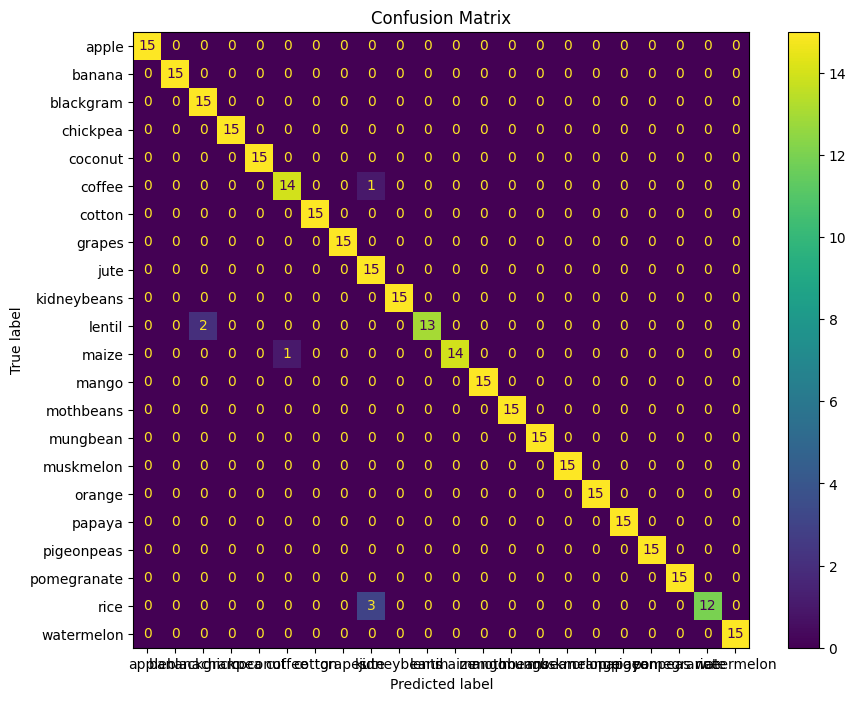

In [85]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
).plot(ax=ax)
plt.title('Confusion Matrix')


In [90]:
#classification report

print(classification_report(y_test, y_pred_final, target_names=le.classes_))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       0.88      1.00      0.94        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       0.93      0.93      0.93        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.79      1.00      0.88        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      0.87      0.93        15
       maize       1.00      0.93      0.97        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00        15
      papaya       1.00    

In [ ]:
import joblib
from pathlib import Path

model_obj = None
for name in ["knn_cls", "model", "best_model", "gs", "grid_search"]:
    if name in globals():
        candidate = globals()[name]
        model_obj = getattr(candidate, "best_estimator_", candidate)
        break

if model_obj is None:
    raise ValueError("No trained model variable found in notebook globals.")

output_path = Path("../../models/knn.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")